In [48]:
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from typing import Annotated
from typing_extensions import TypedDict

#External Tool
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun

from dotenv import load_dotenv
load_dotenv()

## Call Tool
arxiv_wrapper = ArxivAPIWrapper(top_k_results=1, doc_content_chars_max=5000)
arxiv_tool = ArxivQueryRun(api_wrapper=arxiv_wrapper)

wikipedia_wrapper = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=5000)
wikipedia_tool = WikipediaQueryRun(api_wrapper=wikipedia_wrapper)

In [49]:
print(wikipedia_tool.invoke("who is Bill Gates? and explain in detail"))

Page: Bill Gates
Summary: William Henry Gates III  (born October 28, 1955) is an American businessman and philanthropist. A pioneer of the microcomputer revolution of the 1970s and 1980s, he co-founded the software company Microsoft in 1975 with his childhood friend Paul Allen. Following Microsoft's initial public offering in 1986 and the subsequent increase in its stock price, Gates became the world's then-youngest billionaire in 1987, at age 31. Forbes magazine ranked him as the world's wealthiest person for 18 out of 24 years between 1995 and 2017, including 13 years consecutively from 1995 to 2007. Gates became the first centibillionaire in 1999, when his net worth briefly surpassed US$100 billion. According to Forbes, as of February 2026, his net worth stood at US$107.7 billion, making him the 18th-wealthiest individual in the world.
Born and raised in Seattle, Washington, Gates was privately educated at Lakeside School, where he befriended Allen and developed his computing intere

In [19]:
print(arxiv_tool.invoke("Attention Is All You Need Ashish Vaswani"))

Published: 2022-09-06
Title: Adapting Rapid Motor Adaptation for Bipedal Robots
Authors: Ashish Kumar, Zhongyu Li, Jun Zeng, Deepak Pathak, Koushil Sreenath, Jitendra Malik
Summary: Recent advances in legged locomotion have enabled quadrupeds to walk on challenging terrains. However, bipedal robots are inherently more unstable and hence it's harder to design walking controllers for them. In this work, we leverage recent advances in rapid adaptation for locomotion control, and extend them to work on bipedal robots. Similar to existing works, we start with a base policy which produces actions while taking as input an estimated extrinsics vector from an adaptation module. This extrinsics vector contains information about the environment and enables the walking controller to rapidly adapt online. However, the extrinsics estimator could be imperfect, which might lead to poor performance of the base policy which expects a perfect estimator. In this paper, we propose A-RMA (Adapting RMA), whi

In [50]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [59]:
tools = [wikipedia_tool, arxiv_tool]

graph_builder = StateGraph(State)

llm = init_chat_model(
    model="llama-3.1-8b-instant",
    model_provider="groq",
    temperature=0.7,
    max_tokens=1000,
    max_retries=2,
)

llm_with_tools = llm.bind_tools(tools)

In [52]:
def chatbot(state: State):
    print("==== Returning from Chatbot ====")
    message = llm_with_tools.invoke(state["messages"])
    print(message)
    return {"message": [message]}

In [53]:
from langgraph.prebuilt import ToolNode, tools_condition

In [54]:
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("chatbot",END)

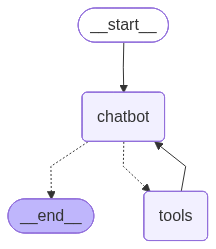

In [55]:
graph = graph_builder.compile()
graph

In [56]:
user_input = "Hi there,My name is Surya. tell about Bill gates"

events = graph.stream({"messages": [("user", user_input)]}, stream_mode="values")

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there,My name is Surya. tell about Bill gates
==== Returning from Chatbot ====
content='' additional_kwargs={'tool_calls': [{'id': 'bskcjfr4h', 'function': {'arguments': '{"query":"Bill gates information"}', 'name': 'arxiv'}, 'type': 'function'}, {'id': 'ztwx1czry', 'function': {'arguments': '{"query":"Bill Gates"}', 'name': 'wikipedia'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 460, 'total_tokens': 488, 'completion_time': 0.045207386, 'completion_tokens_details': None, 'prompt_time': 0.025842488, 'prompt_tokens_details': None, 'queue_time': 0.045217882, 'total_time': 0.071049874}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019c9f31-bec8-7890-a004-f2eb2fad06dc-0' tool_calls=[{'name': 'arxiv', 'args

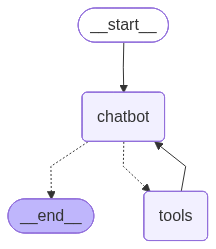

In [62]:

from langchain_core.messages import SystemMessage

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)


SYSTEM_PROMPT = """

You are a helpful assistant.

If a tool provides sufficient information to answer the user,
you MUST synthesize a final answer.

Do NOT repeatedly call the same tool.
Do NOT search again unless information is clearly missing.
"""

def chatbot(state: State):
    print("==== Returning from Chatbot ====")
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    result = llm_with_tools.invoke(messages)
    return {"messages": [result]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_edge(START, "chatbot")

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END,
    },
)

graph_builder.add_edge("tools", "chatbot")

graph = graph_builder.compile()
graph

In [64]:
user_input = "Hi there,My name is Surya. when was Bill gates born?"

events = graph.stream({"messages": [("user", user_input)]}, stream_mode="values")

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there,My name is Surya. when was Bill gates born?
==== Returning from Chatbot ====
================================== Ai Message ==================================
Tool Calls:
  wikipedia (hdtqm0y31)
 Call ID: hdtqm0y31
  Args:
    query: Bill gates birthday
================================= Tool Message =================================
Name: wikipedia

Page: Bill Gates Sr.
Summary: William Henry Gates II (November 30, 1925 – September 14, 2020), better known as Bill Gates Sr., was an American attorney, philanthropist, and civic leader. He was the founder of the law firm Shidler McBroom & Gates (a predecessor of K&L Gates), and also served as president of both the Seattle King County and Washington State Bar associations. He was the father of Bill Gates, co-founder of Microsoft.



Page: Personal life of Jeffrey Epstein
Summary: The financier and child sex offender Jeffrey Epstein cultivated an elite 

### Tested the Wikipedia Loader and It doesn't take any LLM Call Since it is a Simple Text Loader which actually call wikipedia API

In [7]:
from langchain_community.document_loaders import WikipediaLoader

loader = WikipediaLoader(query="Bill Gates", load_max_docs=1)
docs = loader.load()
print(docs[0].page_content)

William Henry Gates III  (born October 28, 1955) is an American businessman and philanthropist. A pioneer of the microcomputer revolution of the 1970s and 1980s, he co-founded the software company Microsoft in 1975 with his childhood friend Paul Allen. Following Microsoft's initial public offering in 1986 and the subsequent increase in its stock price, Gates became the world's then-youngest billionaire in 1987, at age 31. Forbes magazine ranked him as the world's wealthiest person for 18 out of 24 years between 1995 and 2017, including 13 years consecutively from 1995 to 2007. Gates became the first centibillionaire in 1999, when his net worth briefly surpassed US$100 billion. According to Forbes, as of February 2026, his net worth stood at US$107.7 billion, making him the 18th-wealthiest individual in the world.
Born and raised in Seattle, Washington, Gates was privately educated at Lakeside School, where he befriended Allen and developed his computing interests. In 1973, he enrolled 

In [ ]:
class state(TypedDict):
    messages:Annotated[list,add_messages]